# Linear Regression: Diabetes and Synthetic Data

The diabetes example is adapted from scikit-learn's [ordinary least squares example](https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html).

## Diabetes regression

The built-in scikit-learn diabetes dataset is used to demonstrate a complete linear regression workflow.

In [1]:
# Code source: Jaques Grobler
# License: BSD 3 clause

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Load the diabetes dataset
diabetes = datasets.load_diabetes()

## What are we working with?
Let's look at the structure of our data. The data structure returned from our load_diabetes() method is a dictionary. Let's see what the keys are.

In [2]:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


What are the features?

In [3]:
print(diabetes['feature_names'])

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


What do some of the feature vectors look like?

In [4]:
print(diabetes['data'][:5])

[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]


Can also access the *data* and *target* through class fields `data` and `target`

In [5]:
print(diabetes.data[:5])

[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]


What is the output for the first few instances?

In [6]:
print(diabetes.target[:5])

[151.  75. 141. 206. 135.]


## What's with our feature values?
The output looks like what we saw in the original dataset, but the attributes do not. 

For instance, for the first patient, their age is 0.038 and their gender is 0.05? 

*What's going on?*

According to the documentation, the data has been scaled so each attribute has zero mean and a variance of 1. 

https://web.stanford.edu/~hastie/Papers/LARS/diabetes.sdata.txt

This is a common scaling technique (*Standard scaling*). 

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

We will talk more about different transformation techniques that we can apply to our data in the future.  Here we have some features with large values such as 80-130 (BP) and other others with small values such as 1-2 (sex). We can get poor performance if our attributes have significantly different ranges.

## Only use one feature
For an example that is easy to visualize, we will just use one of the features (BMI). Ignoring the other features will most likely give us worse predictions. But our goal is to understand what is going on at this point.



In [7]:
# Use only one feature (BMI). BMI is column 3 (index=2) of the feature vectors.
diabetes_X = diabetes.data[:, np.newaxis, 2]

In [8]:
print(diabetes_X[:5])

[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]]


## Split our dataset
We need to split our dataset into *training* and *test* sets. 

We split both the feature vectors (`data`) and the output (`target`).


*  Training set: used for *learning* the model
*   Test set: used for *evaluating* our trained model



In [9]:
# Split the data into training/testing sets
from sklearn.model_selection import train_test_split
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes_X, diabetes.target, train_size=0.8, random_state=0)

print('Training set size: {}'.format(len(diabetes_X_train)))
print('Test set size: {}'.format(len(diabetes_X_test)))

Training set size: 353
Test set size: 89


## Create instance of the model object
Before training, we must create an instance of our linear regression class.

In [10]:
# Create linear regression object
regr = linear_model.LinearRegression()

## Train the model
We train the model on our training set. 

With Scikit-Learn, *training* is done using the `fit(x,y)` function, where `x` is the list of training feature vectors (*input*) and `y` is the corresponding list of target values (*output*). 

All classifier and regressor classes inherit the `fit` function.

In [11]:
# Train the model using the training sets
regr.fit(diabetes_X_train, diabetes_y_train)

LinearRegression()

In [12]:
# Inspect the fitted line coefficients
print('Coefficients: \n', regr.coef_)

Coefficients: 
 [981.65543614]


## Evaluate the model

The held-out test set estimates how well the fitted regression model generalizes beyond its training samples.

In [13]:
# Make predictions using the testing set
diabetes_y_pred = regr.predict(diabetes_X_test)

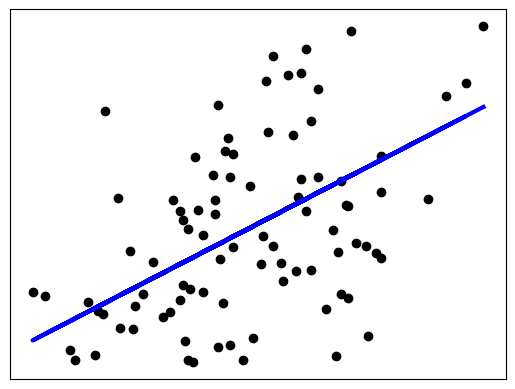

In [14]:
# Plot outputs
plt.scatter(diabetes_X_test, diabetes_y_test,  color='black')
plt.plot(diabetes_X_test, diabetes_y_pred, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

## Measuring error
While plots are nice, there are many possible lines that fit the data. Some better than others. Visually, it can be difficult to tell which is a better fit. 

We would like to quantify the error. For this, we will use the *Root Mean Square Error* (RMSE).

$$ error = \sqrt{\frac{1}{m}\sum\limits_{i=1}^{m}{(predicted_i - correct_i)^2}} $$


Scikit-Learn has a function for calculating *mean squared error* (MSE). To get RMSE, we just compute the square root of the value returned by this function.



In [15]:
# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred)))

Root mean squared error: 64.43


## Use all features?
With this example, we only used one of the 10 attributes (or features). What if our model used all 10? 

In [16]:
# Split the data into training/testing sets
from sklearn.model_selection import train_test_split
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes.data, diabetes.target, train_size=0.8, random_state=0)

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(diabetes_X_train, diabetes_y_train)

# Make predictions using the testing set
diabetes_y_pred = regr.predict(diabetes_X_test)

# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(diabetes_y_test, diabetes_y_pred)))

Root mean squared error: 58.52


# Regression with synthetic data

Synthetic datasets make it possible to vary controlled properties and examine how they affect a regression model.

## Generate the data

`make_regression` creates 1,000 samples with one feature, one target, and Gaussian noise. A single feature keeps the relationship easy to visualize.

In [18]:
from sklearn.datasets import make_regression

# Retain this statement for the later noise comparisons.
data, targets = make_regression(n_samples=1000, n_features=1, n_targets=1, noise=5.0)

## Inspect the generated data

The first five feature values show the generated input range.

In [33]:
print(data[:5])

[[-0.74029633]
 [ 1.0764824 ]
 [-0.27931624]
 [-0.89404586]
 [-1.79429601]]


The first five values below are the corresponding regression targets.

In [25]:
print(targets[:5])

[-22.32598342  22.76356812 -13.23337835 -22.03917486 -34.18405394]


## Train-test split

The generated data is divided into 80% training and 20% test samples.

In [34]:
# Split the data into training/testing sets
data_train, data_test, targets_train, targets_test = train_test_split(
    data, targets, test_size=0.2, random_state=42
)

The resulting partition contains 800 training samples and 200 test samples.

In [45]:
print("Train Data Size: ", len(data_train))
print("Test Data Size: ", len(data_test))

Train Data Size:  800
Test Data Size:  200


## Train the synthetic-data model

In [46]:
# Create the model
# Create linear regression object
regr = linear_model.LinearRegression()

In [47]:
# Train the model
regr.fit(data_train, targets_train)

LinearRegression()

## Evaluate the synthetic-data model

In [49]:
# Make predictions using the testing set
data_pred = regr.predict(data_test)

# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(data_test, data_pred)))

Root mean squared error: 19.59


The test samples and predicted regression line provide a visual check of model fit.

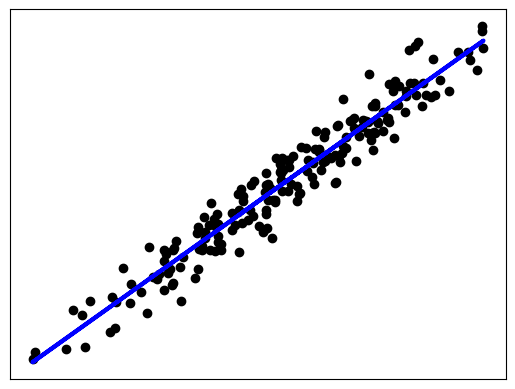

In [51]:
# Plot outputs
plt.scatter(data_test, targets_test, color='black')
plt.plot(data_test, data_pred, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()


## Noise sensitivity

The workflow is repeated with noise levels of 10.0 and 0.5.

Root mean squared error: 26.76


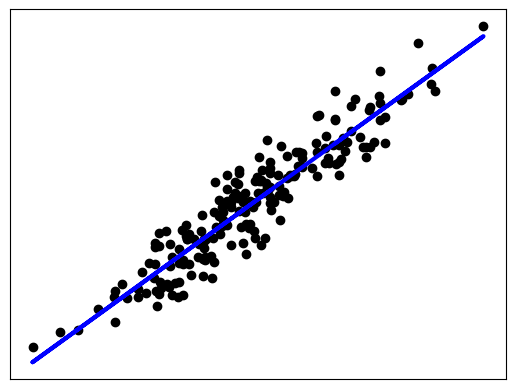

In [52]:
# create the data
data, targets = make_regression(n_samples=1000, n_features=1, n_targets=1, noise=10.0)

# split the data
data_train, data_test, targets_train, targets_test = train_test_split(
    data, targets, test_size=0.2, random_state=42
)

# Create the model
regr = linear_model.LinearRegression()

# Train the model
regr.fit(data_train, targets_train)

# Make predictions using the testing set
data_pred = regr.predict(data_test)

# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(data_test, data_pred)))


# Plot outputs
plt.scatter(data_test, targets_test, color='black')
plt.plot(data_test, data_pred, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

### Experiment with noise=0.5

Root mean squared error: 46.95


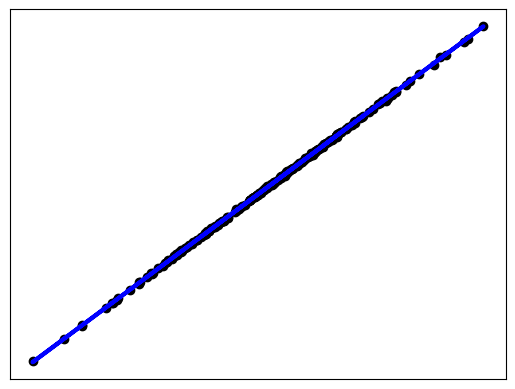

In [53]:
# create the data
data, targets = make_regression(n_samples=1000, n_features=1, n_targets=1, noise=0.5)

# split the data
data_train, data_test, targets_train, targets_test = train_test_split(
    data, targets, test_size=0.2, random_state=42
)

# Create the model
regr = linear_model.LinearRegression()

# Train the model
regr.fit(data_train, targets_train)

# Make predictions using the testing set
data_pred = regr.predict(data_test)

# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(data_test, data_pred)))


# Plot outputs
plt.scatter(data_test, targets_test, color='black')
plt.plot(data_test, data_pred, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

### Observed results

The experiments produce RMSE values of 19.59, 26.76, and 46.95. Because each `make_regression` call generates a new underlying relationship without a fixed random state, these runs do not isolate the effect of noise alone.

## Linear prediction example

Given $w = [-1, 3, 2]^T$, $x_0=1$, age $x_1=53$, and BMI $x_2=27$, the predicted output is:

In [62]:
feat = np.array([1,53,27])
w = np.array([-1,3,2]).transpose()
print("Predicted output = ", np.dot(feat,w))

Predicted output =  212


$$-1 + 3(53) + 2(27) = 212$$